In [44]:
!head ../ratings_long.csv

userId,movieId,rating
0,16,5
0,72,5
0,86,5
0,259,1
0,319,4
0,521,4
0,534,2
0,671,1
0,673,2


In [45]:
import numpy as np
import pandas as pd

In [46]:
r = np.full((20, 1000),fill_value=np.nan)

In [47]:
df = pd.read_csv('../ratings_long.csv')

In [48]:
for rec in df.itertuples():
    r[rec.userId][rec.movieId] = rec.rating

Note that $r$ matrix is $20 \times 1000$ with only <1\% full (highly sparse)

In [49]:
r

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan,  4., nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]])

What if we define two matricies
- u = $20 \times 4$
- v = $4 \times 1000$


Then model $r$ as $u \times v$

Problem is we have to learn for $20 \times 4 + 4 \times 1000 = 4080$ parameters (better than 20.000 x 0.99 missing values)

## Problem

1. Define a convex loss function wrt $u$ and $v$
- Solve using gradient descent algorithm explained in **I Do**
- Use any regulatizer $L1$ or $L2$ to prevent overfitting

# SOLUTION

### Data Exploring

### -> _Data has 20 unique users and 179 unique rated films. Also we know the data is sparse about %99._
### -> _Rating Distribution is nearly Gaussian Distribution._

In [50]:
import numpy as np
import pandas as pd

df = pd.read_csv("../ratings_long.csv")
print(f"Length of df: {len(df)}")
print(f"Shape of df: {df.shape}")
print(f"Unique User Count: {df['userId'].nunique()}")
print(f"Unique Movie Count: {df['movieId'].nunique()}")
print(" ")
print(f"Distribution of Ratings {df['rating'].value_counts().sort_index()}")


Length of df: 200
Shape of df: (200, 3)
Unique User Count: 20
Unique Movie Count: 179
 
Distribution of Ratings rating
1    29
2    41
3    56
4    37
5    37
Name: count, dtype: int64


### Train-Test Split

In [51]:
from sklearn.model_selection import train_test_split

train_data, test_data = train_test_split(df, test_size=0.2)

print(f"Train dataset size: {len(train_data)}")
print(f"Test dataset size: {len(test_data)}")

Train dataset size: 160
Test dataset size: 40


In [52]:
test_data.head(5)

,userId,movieId,rating
105,9,691,3
19,1,286,5
37,2,455,4
2,0,86,5
184,18,395,4


### Initializing Matrices 

#### -> _We initialize the matrices with small random values to make gradient descent optimization works better_

In [53]:
features_count = 4
u = np.random.normal(scale=0.1, size=(20, features_count))
v = np.random.normal(scale=0.1, size=(features_count, 1000))

print(f"U matrix dimensions: {u.shape}")
print(f"V matrix dimensions: {v.shape}")

u[:5]
# v[:5]

U matrix dimensions: (20, 4)
V matrix dimensions: (4, 1000)


array([[-0.11490292, -0.0987892 , -0.04333406,  0.15561266],
       [-0.02767501, -0.03776974,  0.00474962, -0.01646277],
       [-0.13975667,  0.18493652,  0.1045336 ,  0.01643109],
       [ 0.09742789,  0.04676552, -0.03936622,  0.11020982],
       [ 0.0667843 ,  0.03624582, -0.031461  , -0.0221278 ]])

### Defining Error Metrics

#### -> _We add movie biases for movies. This improves the model make better predictions instead of predicting zero for items that didn't appear in training data._

In [54]:
def loss_fn(y_true, y_pred) -> float:
    return np.mean( (y_true - y_pred)**2 )

def calculate_loss(dataset, u, v, global_mean, movie_bias):
    predictions = []
    for row in dataset.itertuples():
        user = row.userId
        movie = row.movieId
        prediction = global_mean + movie_bias[movie] + np.dot(u[user], v[:, movie])
        predictions.append(prediction)
        
    predictions = np.array(predictions)
    mse = loss_fn(dataset['rating'].values, predictions)
    rmse = np.sqrt(mse)
    return mse, rmse

### Optimization by Gradient Descent

In [55]:
epochs = 1000
learning_rate = 0.001
reg_coef = 0.1

global_mean = train_data['rating'].mean()

movie_bias = np.zeros(1000)

train_mse_history = []
train_rmse_history = []

for epoch in range(epochs):
    for row in train_data.itertuples():
        user = row.userId
        movie = row.movieId
        actual_rating = row.rating
        
        prediction = global_mean + movie_bias[movie] + np.dot(u[user, :], v[:, movie])
        error = actual_rating - prediction
        
        old_u = u[user, :].copy()
        old_v = v[:, movie].copy()
        
        gradient_u = -error * old_v + 2 * reg_coef * old_u
        gradient_v = -error * old_u + 2 * reg_coef * old_v
        gradient_bi = -error + 2 * reg_coef * movie_bias[movie]
        
        # Güncellemeler
        u[user, :] -= learning_rate * gradient_u
        v[:, movie] -= learning_rate * gradient_v
        movie_bias[movie] -= learning_rate * gradient_bi
        
    train_mse, train_rmse = calculate_loss(train_data, u, v, global_mean, movie_bias)
    train_mse_history.append(train_mse)
    train_rmse_history.append(train_rmse)
    
    if epoch % 100 == 0 or epoch == epochs - 1: # Because Epoch starts from 0
        print(f"Epoch {epoch} - Train MSE: {train_mse} - Train RMSE: {train_rmse}")

Epoch 0 - Train MSE: 1.7126647743504404 - Train RMSE: 1.3086881883590302
Epoch 100 - Train MSE: 1.4098909546247165 - Train RMSE: 1.1873882914298577
Epoch 200 - Train MSE: 1.1757371158550596 - Train RMSE: 1.0843141223165267
Epoch 300 - Train MSE: 0.9886780626963632 - Train RMSE: 0.9943229167108456
Epoch 400 - Train MSE: 0.8355566757885551 - Train RMSE: 0.9140878928136807
Epoch 500 - Train MSE: 0.7074726367339076 - Train RMSE: 0.8411139261324281
Epoch 600 - Train MSE: 0.5982473366002186 - Train RMSE: 0.7734645024823172
Epoch 700 - Train MSE: 0.5036111322778035 - Train RMSE: 0.709655643448147
Epoch 800 - Train MSE: 0.4207413395675655 - Train RMSE: 0.648645773567951
Epoch 900 - Train MSE: 0.34819078426199956 - Train RMSE: 0.5900769307997048
Epoch 999 - Train MSE: 0.2865235343102984 - Train RMSE: 0.5352789313155324


### VISUALIZING TRAIN LOSS FUNCTIONS 

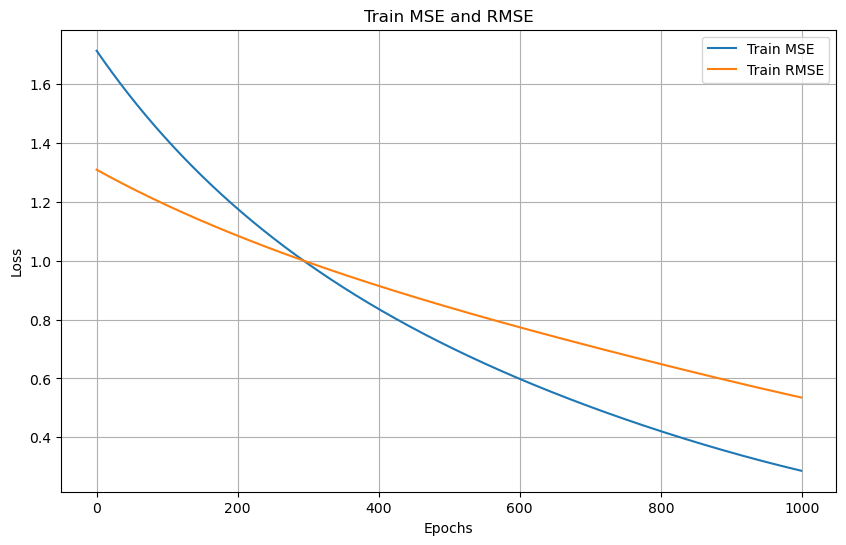

In [56]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(train_mse_history, label='Train MSE')
plt.plot(train_rmse_history, label='Train RMSE')
plt.title('Train MSE and RMSE')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid()
plt.legend()
plt.show()

### EVALUATING AND COMPRASION W BASELINE MODEL (AVERAGE BASED)

#### -> _Those results mean baseline predictions is almost equal with Gradient Descent Optimized GLM._
#### -> _Some training are better at baseline and some at GLM. It's chance._

In [57]:
test_mse, test_rmse = calculate_loss(test_data, u, v, global_mean, movie_bias)

mean_rating = train_data['rating'].mean()
print(f"Average Rating: {mean_rating}")

baseline_predictions = np.full(len(test_data), fill_value=mean_rating)
actual_test_ratings = test_data['rating'].values

baseline_mse = loss_fn(actual_test_ratings, baseline_predictions)
baseline_rmse = np.sqrt(baseline_mse)

print(f"Baseline Test MSE: {baseline_mse} - Gradient Descent Optimized GLM Test MSE: {test_mse}")
print(f"Baseline Test RMSE: {baseline_rmse} - Gradinet Descent Optimized GLM Test RMSE: {test_rmse}")

improvement_mse = ((baseline_mse - test_mse) / baseline_mse) * 100
print(" ")
print(f"MSE Improvement Over Baseline Model: {improvement_mse:.2f}%")

Average Rating: 3.04375
Baseline Test MSE: 1.6659765624999998 - Gradient Descent Optimized GLM Test MSE: 1.5844629947377782
Baseline Test RMSE: 1.2907271448683488 - Gradinet Descent Optimized GLM Test RMSE: 1.2587545410991685
 
MSE Improvement Over Baseline Model: 4.89%
